In [4]:
from google.colab import files
uploaded = files.upload()



Saving student_exam_scores.csv to student_exam_scores.csv


In [5]:
import pandas as pd

df = pd.read_csv("student_exam_scores.csv")
df.head()


,Hours_Studied,Attendance_%,Sleep_Hours,Previous_Score,Final_Exam_Score
0,3.75,90.37,8.70,63.29,104.52
1,9.51,94.80,8.77,78.60,138.52
2,7.32,65.90,8.57,67.50,119.86
3,5.99,55.50,5.85,72.74,89.39
4,1.56,61.40,4.08,96.49,81.41


Iteration 0:w1=0.045,w2=0.699,w3=0.062,w4=0.668,b=0.009
Iteration 100:w1=0.161,w2=0.781,w3=0.197,w4=0.455,b=0.029
Iteration 200:w1=0.270,w2=0.776,w3=0.327,w4=0.440,b=0.048
Iteration 300:w1=0.368,w2=0.767,w3=0.452,w4=0.433,b=0.067
Iteration 400:w1=0.456,w2=0.757,w3=0.573,w4=0.425,b=0.086
Iteration 500:w1=0.535,w2=0.749,w3=0.688,w4=0.419,b=0.105
Iteration 600:w1=0.605,w2=0.740,w3=0.799,w4=0.413,b=0.123
Iteration 700:w1=0.667,w2=0.732,w3=0.906,w4=0.407,b=0.141
Iteration 800:w1=0.723,w2=0.725,w3=1.009,w4=0.402,b=0.158
Iteration 900:w1=0.773,w2=0.718,w3=1.108,w4=0.397,b=0.176


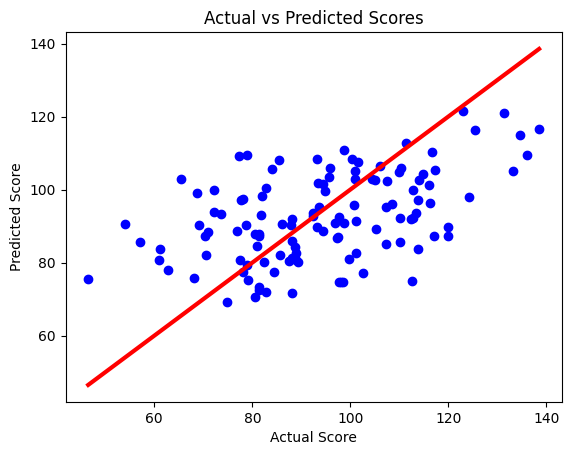

Score with 15hours study,60% attendance,6hours of sleep, and a previous score of 85= 95.643


In [19]:
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data=pd.read_csv("student_exam_scores.csv")
x1=data["Hours_Studied"].values
x2=data["Attendance_%"].values
x3=data["Sleep_Hours"].values
x4=data["Previous_Score"].values
y=data["Final_Exam_Score"].values


x1=x1.reshape(-1,1)
x2=x2.reshape(-1,1)
x3=x3.reshape(-1,1)
x4=x4.reshape(-1,1)

w1=0.0
w2=0.0
w3=0.0
w4=0.0
b=0.0

itrns=1000
lr=0.0001

def pred(x1,x2,x3,x4):
  return w1*x1+w2*x2+w3*x3+w4*x4+b

for i in range(itrns):
    y_pred=pred(x1,x2,x3,x4)

    dw1=np.mean((y_pred-y)*x1)
    dw2=np.mean((y_pred-y)*x2)
    dw3=np.mean((y_pred-y)*x3)
    dw4=np.mean((y_pred-y)*x4)
    db=np.mean(y_pred-y)

    w1-=lr*dw1
    w2-=lr*dw2
    w3-=lr*dw3
    w4-=lr*dw4
    b-=lr*db

    if i%100==0:
      print(f"Iteration {i}:w1={w1:.3f},w2={w2:.3f},w3={w3:.3f},w4={w4:.3f},b={b:.3f}")


plt.scatter(y, y_pred.flatten(), color='blue')
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=3)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")
plt.show()


print("Score with 15hours study,60% attendance,6hours of sleep, and a previous score of 85=",round(pred(15,60,6,85),3))



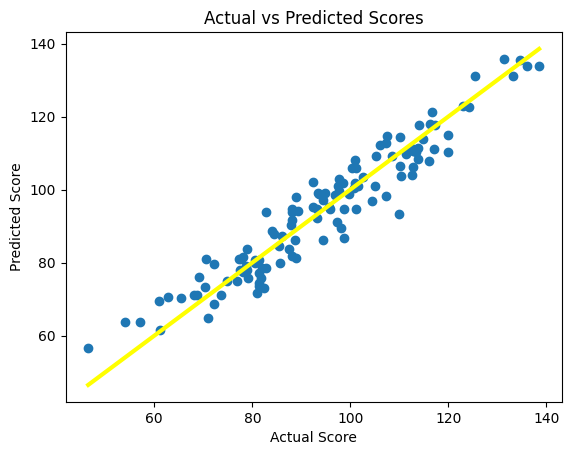

w= [5.07704978 0.25374583 3.22848353 0.41015318]
b= 0.9430278558159699
Score with 15hours study,60% attendance,6hours of sleep, and a previous score of 85= 146.557


In [11]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data=pd.read_csv("student_exam_scores.csv")
x=data[["Hours_Studied","Attendance_%","Sleep_Hours","Previous_Score"]].values
y=data["Final_Exam_Score"].values

model=LinearRegression()
model.fit(x,y)

y_pred=model.predict(x)


plt.scatter(y, y_pred)
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='yellow', linewidth=3)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")
plt.show()

print("w=",model.coef_)
print("b=",model.intercept_)
new_s1=np.array([[15,60,6,85]])
score=model.predict(new_s1)
print("Score with 15hours study,60% attendance,6hours of sleep, and a previous score of 85=",round(score[0],3))